🌍 Downloading raw grid data...
⚙️ Engineering time-series features and lags...
✅ Data processed successfully! Training on 46006 real-world hours.

🚀 Starting Model Training Bake-Off...

🧠 Training Linear Regression...
✅ Linear Regression finished! Error: 10.47g | Accuracy: 93.4%

🧠 Training Random Forest...
✅ Random Forest finished! Error: 10.39g | Accuracy: 93.4%

🧠 Training XGBoost...
✅ XGBoost finished! Error: 10.17g | Accuracy: 93.7%



/var/folders/ym/4k7w4nhn1d90w6_pk56j2dym0000gn/T/ipykernel_51896/2641806965.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="MAE", palette="viridis")


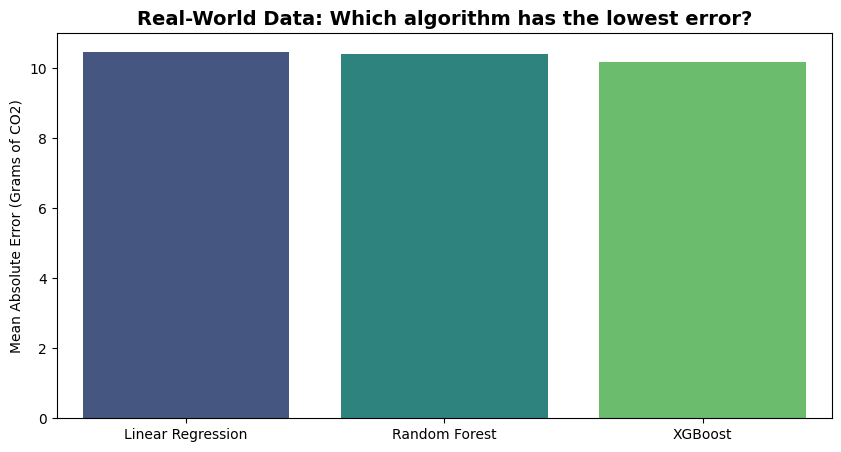

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import io
import urllib3
import holidays 

# 🛑 Silence the annoying "unverified HTTPS" warnings
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# Import the Models
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

# Import Evaluation Metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==========================================
# 1. LOAD THE RAW DATA (Bypassing Mac SSL)
# ==========================================
hf_url = "https://huggingface.co/datasets/appleballcay/denmark-grid-co2-2021-2026/raw/main/final_master_dataset.csv"
print("🌍 Downloading raw grid data...")

response = requests.get(hf_url, verify=False)
csv_data = io.StringIO(response.text)
df = pd.read_csv(csv_data)

# Isolate DK2
if 'price_area' in df.columns:
    df = df[df['price_area'].str.upper() == 'DK2'].copy()

# ==========================================
# 2. FEATURE ENGINEERING
# ==========================================
print("⚙️ Engineering time-series features and lags...")

# --- FIXED: Hardcoded to match the Hugging Face dataset ---
time_col = 'ds'

# Ensure date is a proper datetime object and sort it chronologically
df[time_col] = pd.to_datetime(df[time_col])
df = df.sort_values(time_col)

# A. Time Features
df['hour'] = df[time_col].dt.hour
df['day_of_week'] = df[time_col].dt.weekday
df['month'] = df[time_col].dt.month
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# B. Holiday & Weekend Features
dk_holidays = holidays.Denmark()
df['is_holiday'] = df[time_col].dt.date.apply(lambda x: 1 if x in dk_holidays else 0)
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# C. Lag Features (Looking backward in time)
df['co2_lag_1h'] = df['co2_emissions_g_kwh'].shift(1)
df['co2_lag_2h'] = df['co2_emissions_g_kwh'].shift(2)
df['co2_lag_24h'] = df['co2_emissions_g_kwh'].shift(24)
df['co2_lag_168h'] = df['co2_emissions_g_kwh'].shift(168) # 1 week ago

# Drop the first 168 rows because they don't have enough history to create the 168h lag
df = df.dropna()

print(f"✅ Data processed successfully! Training on {len(df)} real-world hours.")

# ==========================================
# 3. PREPARE FEATURES & TARGET
# ==========================================
feature_cols = [
    'spot_price_dkk_kwh', 'wind_speed', 'solar_radiation', 
    'hour', 'day_of_week', 'month', 'hour_sin', 'hour_cos', 
    'is_holiday', 'is_weekend', 
    'co2_lag_1h', 'co2_lag_2h', 'co2_lag_24h', 'co2_lag_168h'
]

target_col = 'co2_emissions_g_kwh'

X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# 4. INITIALIZE THE COMPETITORS
# ==========================================
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
}

results = []

# ==========================================
# 5. THE BAKE-OFF (Train & Test Loop)
# ==========================================
print("\n🚀 Starting Model Training Bake-Off...\n")

for name, model in models.items():
    print(f"🧠 Training {name}...")
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    
    results.append({"Model": name, "MAE": mae, "R2 Score": r2})
    print(f"✅ {name} finished! Error: {mae:.2f}g | Accuracy: {r2*100:.1f}%\n")

# ==========================================
# 6. VISUALIZE THE WINNER
# ==========================================
results_df = pd.DataFrame(results)

plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="Model", y="MAE", palette="viridis")
plt.title("Real-World Data: Which algorithm has the lowest error?", fontsize=14, fontweight='bold')
plt.ylabel("Mean Absolute Error (Grams of CO2)")
plt.xlabel("")
plt.show()